# Kepler-51 planetary system in the light of the PhotoRing effect
## Reproducing the figures of Numpaque et al. (2026)

This notebook contains the code for reproducing the figures in the paper:

> S. Numpaque, J.I. Zuluaga, D. Kipping and J.A. Alvarado "Asterodensity profile analysis of the Kepler-51 planetary system:1
a case study on the detection of exoplanetary rings via the PhotoRing effect", in preparation.

For detailed explanations see the GitHub repository: [https://github.com/seap-udea/PRisma](https://github.com/seap-udea/PRisma).

## Preparing the environment

In [1]:
# ── Bootstrap: make the repository packages importable without installation ──
import sys, pathlib
_HERE = pathlib.Path.cwd()
_cands = [_HERE, *_HERE.parents]
_REPO = next((c for c in _cands if (c / "pipeline" / "photoring").is_dir() and (c / "pipeline" / "exorings").is_dir()), _HERE.parent)
for _p in (str(_REPO / "pipeline"), str(_REPO)):
    if _p not in sys.path:
        sys.path.insert(0, _p)
print("repo root:", _REPO)


repo root: /Users/jzuluaga/dev/PRisma


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
import importlib

import photoring as pr
import photoring.plotting as plot
from photoring import literature, contour
from photoring.io import load_observables, load_run

# Reload plotting to pick up latest style/layout/scoring edits during notebook work.
plot = importlib.reload(plot)

# The manuscript's look: saturated palette, LaTeX, 95% corner intervals.
plot.apply_style(plot.PAPER_STYLE)

CASE = "kepler_51"
# This notebook does not live in pipeline/, so point CasePaths at it explicitly.
paths = pr.CasePaths(CASE, pipeline_dir=_REPO / "pipeline")
IMG = pathlib.Path(_REPO / "papers" / "kepler51" / "figures")
# Load runs from pipeline results (same source used by the figure-generation scripts).
RESULTS = paths.results_dir("exorings")
IMG.mkdir(parents=True, exist_ok=True)
print("reading runs from:", RESULTS)
print("writing figures to:", IMG)


reading runs from: /Users/jzuluaga/dev/PRisma/pipeline/kepler_51/results/exorings
writing figures to: /Users/jzuluaga/dev/PRisma/papers/kepler51/figures


## 1. Configuration — the adopted runs

The manuscript's ring-geometry figures use the **fully free** model
($f_e,\ i_R,\ \theta,\ p,\ \tau,\ \rho_{\star,\rm true},\ b$ all sampled) with the likelihood
$\mathcal{L}_{\rm KDE} = (\delta,\ T_{14},\ \rho_{\star,\rm obs})$, nested sampling at
$N_{\rm live}=1200$ and $\Delta\ln Z = 0.01$, and $N_{\rm KDE}=5000$ training samples.

That combination was adopted because it is the only one in the retrieval suite that
reproduces the **full** set of transit observables — including the ones left out of the
likelihood. Simpler configurations fit their own likelihood observables but mispredict the
durations.


In [3]:
RUN_SUFFIX = (
    # "NS_exorings_kde_delta-T14-rho_obs_nlive1200_dlogz0.01"
    # "_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE"
    "NS_exorings_kde_delta-T14-T23-rho_obs_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE_alphaFREE_pFREE"
)
PLANETS = ["b", "d"]

runs = {}
npz_used = []
for pl in PLANETS:
    npz = RESULTS / f"{CASE}_{pl}_{RUN_SUFFIX}.npz"
    npz_used.append(npz)
    if not npz.exists():
        print(f"MISSING: {npz.name}")
        continue
    runs[pl] = load_run(npz)
    r = runs[pl]
    print(f"planet {pl}: ndim={len(r['param_names'])}  lnZ={r['logz']:.3f}  "
          f"L_KDE={r['kde_obs']}  n={len(r['chain'])}")

if not runs:
    print("No runs loaded. Check RUN_SUFFIX and RESULTS path.")

ttv = {pl: load_observables(paths.observables_file(pl)) for pl in PLANETS}
rho_true_samples = np.loadtxt(paths.rho_true_samples) / 1000.0   # kg/m^3 -> g/cm^3
print("\nTTV observables loaded:", {k: len(v["delta"]) for k, v in ttv.items()})

RUN_VERSION = plot.run_version_id(npz_used)
print("RUN_VERSION:", RUN_VERSION)


planet b: ndim=7  lnZ=8.022  L_KDE=['delta', 'T14', 'T23', 'rho_obs']  n=16668
planet d: ndim=7  lnZ=6.552  L_KDE=['delta', 'T14', 'T23', 'rho_obs']  n=15685

TTV observables loaded: {'b': 17756, 'd': 39002}
RUN_VERSION: 2026080712


## PPC analysis

In [4]:
# PPC figures come from photoring.plotting.plot_ppc
# (2+3 layout: rho_obs + delta on top; T14, T23, b_obs below).


-> /Users/jzuluaga/dev/PRisma/papers/kepler51/figures/ppc_planet_b_vertical.png


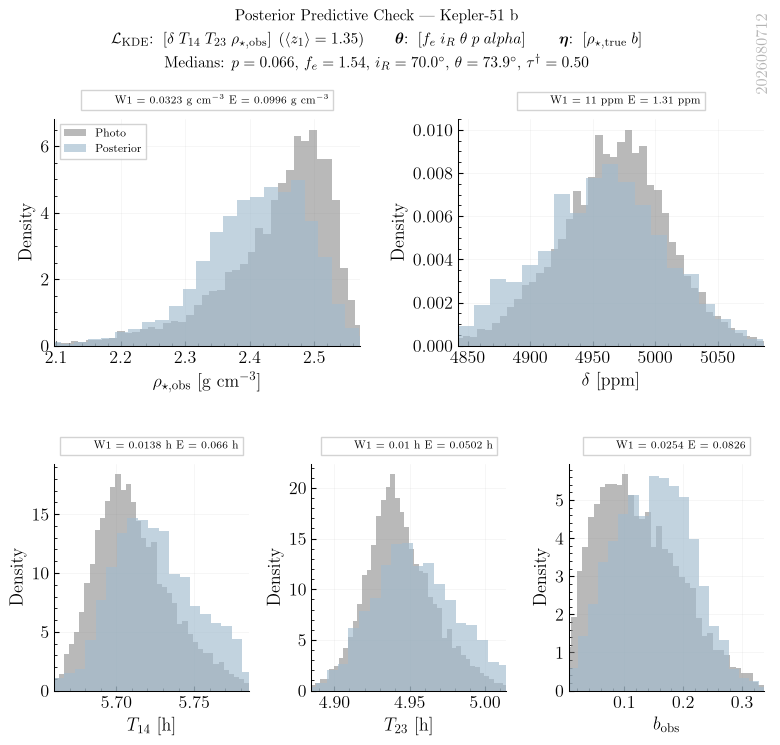

-> /Users/jzuluaga/dev/PRisma/papers/kepler51/figures/ppc_planet_d_vertical.png


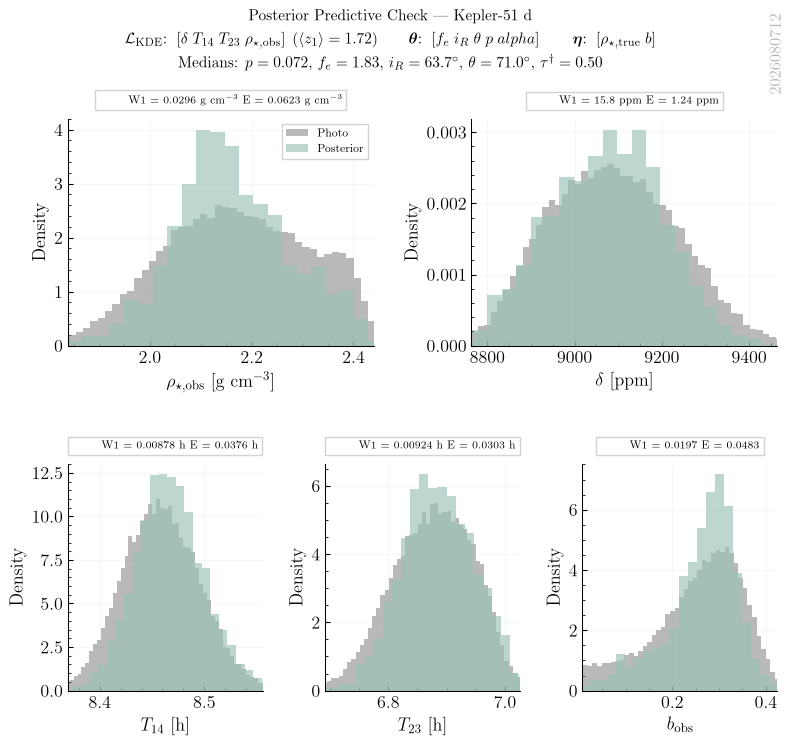

In [5]:
PPC_NAME = {"b": "ppc_planet_b_vertical.png", "d": "ppc_planet_d_vertical.png"}
PPC_OBSERVABLES = ["delta", "T14", "T23", "rho_obs", "b_obs"]

for pl, run in runs.items():
    fig, stats = plot.plot_ppc(run, ttv[pl], obs_keys=PPC_OBSERVABLES)
    if fig is None:
        print(f"SKIP PPC for planet {pl}: figure was not generated.")
        continue

    out = IMG / PPC_NAME[pl]
    plot.add_run_version_label(fig, RUN_VERSION)
    fig.savefig(out, dpi=plot.STYLE["fig_dpi"], bbox_inches="tight")
    print("->", out)
    plt.show()
